# Human Facial Emotion Recognition with CNN

*Author: Ei Phyu Sin Oo*

---

# 1. Introduction

Human Emotions are the root of communication that have a profound effect on social interactions, decisions, behaviors and relationships. With Artificial Intelligence developing more and more, incorporation of emotional intelligence into machines will be the most important step in making technology more human-sensitive. Proper recognition and analysis of facial emotions can find valuable use in many fields, including mental health evaluation, human-computer interaction, surveillance, marketing campaign and automated customer service. Despite its significance, the proper identification of emotions remains a difficult task due to variations in facial expressions, lighting, occlusions, and differences in cultures of expressing emotions.

Traditional solutions to emotion detection are more likely to rely on human monitoring or basic rule-based solutions, which are less effective and not scalable. The use of AI and deep learning model, particularly Convolutional Neural Networks (CNNs) is a potent solution with effective utilization of large datasets in learning nuanced patterns in facial expressions.

In this project, **Convolutional Neural Network (CNN)** is trained to classify static facial images as being in one of the universal emotions (Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral).

The problem statement addressed by this project is the need for accurate, automatic detection and emotion classification of human facial emotions. Effective emotion detection can achieve many positive implications:
* Enhance mental health monitoring by the early detection of emotional distress or mental illness.
* Increase user experience of human-computer interaction through better adaptation, empathy, and personalization.
* Facilitate safer spaces through behavior analysis according to emotional states.
* Facilitating targeted marketing campaigns through affective analytics.

Key contributions:

* **Dataset fusion** – combined two popular face emotion datasets (FER and FER+) to increase the diversity, and specifically augmented underrepresented emotions (especially the disgust emotion) to end up with a well-rounded and large enough dataset.
* **Reproducible pipeline** – data downloading, data preprocessing, exploratory analysis, model building, training, evaluation, and prediction are completely scripted.
* **Modular and Flexible Codebase**: Structured the entire project into clear, reusable functions, which made it easy to experiment with various model architectures, hyperparameters, and data augmentation techniques.


# 2. Datasets

* [Face Expression Recognition (FER)](https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset)  
* [Facial Recognition Dataset (FER+)](https://www.kaggle.com/datasets/apollo2506/facial-recognition-dataset)

| Dataset | Samples | Classes | Original Format | License |
|---------|---------|---------|-----------------|---------|
| Face Expression Recognition (FER) | 35,887 | 7 | 48×48 grayscale PNG | unknown |
| Facial Emotion Recognition (FER+) | 35,257 | 6 | 48×48 grayscale PNG | CC0 |

Both databases offer **48x48** grayscale crops of faces that are labelled with one of the seven emotions. The two datasets were combined to form a stronger training corpus to enhance expression diversity by demographics. The FER dataset contains well organized train/test folders for each emotion, whereas FER+ has its own training/testing structure. Moreover, augmentation was applied to class imbalance, particularly the minority class *disgust*, to have around 6000 images with the `ImageDataGenerator` of Keras.
  
The directory structure is joined together, and the image files are combined into a single Pandas **DataFrame** with columns:

* `filepath` – absolute path to PNG
* `label` – emotion category
* `source` – name of data set of origin


In [ ]:
#environment setup
import os, zipfile, shutil, random, math, json, itertools, datetime, pathlib, warnings, gc, sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model


print("TensorFlow:", tf.__version__)

TensorFlow: 2.18.0


## Download and Extract Datasets
In order to connect and retrieve datasets on Kaggle and save them directly in the Colab environment, Kaggle API has to be set up. Thus, `kaggle.json` file that includes a unique Kaggle username and API key is uploaded.

In [ ]:
# --- ONE-TIME Kaggle setup inside Colab ---
!pip install -q kaggle          # install CLI
from google.colab import files  # prompt for the json
files.upload()

# move it to the standard location & fix permissions
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


Then, the datasets were downloaded using the Kaggle CLI and extracted into organized directories.




In [ ]:
# Download datasets
!pip -q install kaggle --upgrade

import subprocess, textwrap

def kaggle_download(dataset, target_dir):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir, exist_ok=True)
        print(f"Downloading {dataset} …")
        subprocess.run(["kaggle", "datasets", "download", "-d", dataset, "-p", target_dir, "--force"], check=True)
        # Unzip
        for f in pathlib.Path(target_dir).glob("*.zip"):
            print("Extracting", f.name)
            with zipfile.ZipFile(f, 'r') as z:
                z.extractall(target_dir)
            f.unlink()

kaggle_download("jonathanoheix/face-expression-recognition-dataset", "data/fer")
kaggle_download("apollo2506/facial-recognition-dataset", "data/ferplus")


Extracting face-expression-recognition-dataset.zip
Extracting facial-recognition-dataset.zip


In [ ]:
# Check directory structure
print("FER dataset samples:")
print(glob("data/fer/**/*.jpg", recursive=True)[:5])

print("\nFER+ dataset samples:")
print(glob("data/ferplus/**/*.jpg", recursive=True)[:5])


FER dataset samples:
['data/fer/images/images/validation/sad/11662.jpg', 'data/fer/images/images/validation/sad/26670.jpg', 'data/fer/images/images/validation/sad/16405.jpg', 'data/fer/images/images/validation/sad/21968.jpg', 'data/fer/images/images/validation/sad/922.jpg']

FER+ dataset samples:
['data/ferplus/Testing/Testing/Angry/Angry-515.jpg', 'data/ferplus/Testing/Testing/Angry/Angry-433.jpg', 'data/ferplus/Testing/Testing/Angry/Angry-144.jpg', 'data/ferplus/Testing/Testing/Angry/Angry-122.jpg', 'data/ferplus/Testing/Testing/Angry/Angry-215.jpg']


## Data Augumentation

In order to reduce the effect of underrepresentation of the *disgust* class (one of the smallest classes in the FER dataset) an augmentation policy was used with the Keras `ImageDataGenerator`, which creates around 13 synthetic variations of each original image (e.g. rotations, flips, zooms).

In [ ]:
# Function to augment "disgust" class images using ImageDataGenerator
def augment_disgust_images(source_dir, save_dir, augmentations=5):
    if os.path.exists(save_dir):
        print(f"Deleting existing folder: {save_dir}")
        shutil.rmtree(save_dir)  # Remove existing folder to avoid duplicates

    os.makedirs(save_dir, exist_ok=True)

    # Define augmentation parameters
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    image_paths = glob(f'{source_dir}/*.jpg')
    for img_path in image_paths:
        img = load_img(img_path, color_mode='grayscale', target_size=(48, 48))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        prefix = os.path.splitext(os.path.basename(img_path))[0]
        i = 0
        # Generate and save augmented images
        for batch in datagen.flow(x, batch_size=1, save_to_dir=save_dir,
                                  save_prefix=prefix, save_format='jpg'):
            i += 1
            if i >= augmentations:
                break

# Perform augmentation on the disgust class
augment_disgust_images(
    source_dir='data/fer/images/train/disgust',
    save_dir='data/fer/images/train/disgust_aug',
    augmentations=13 # # To balance approximately ≈6000 images
)

# 3. Preliminary Analysis



## Data Merging and Cleansing  

After augmentation, both datasets were loaded and merged into a single DataFrame during which inconsistent spellings of labels (i.e., surprise to suprise and merging augmented folders under the same label) were also standardized. This pre-processing step not only made the data consistent and complete but also extended the training diversity which is necessary to train a deep learning model to be generalized to new unfamiliar facial expressions.

In [ ]:
# Function to load FER dataset
def load_fer_dataset():
    fer_paths = glob("data/fer/images/train/*/*.jpg")
    data = []
    for path in fer_paths:
        label = os.path.basename(os.path.dirname(path))

        # Normalize folder name
        if label == 'disgust_aug':
            label = 'disgust'

        data.append({'filepath': path, 'label': label, 'source': 'FER'})

    return pd.DataFrame(data)

# Function to load FER+ dataset
def load_ferplus_dataset():
    train_paths = glob("data/ferplus/Training/*/*/*.jpg")  # Add one more * for the extra folder
    test_paths = glob("data/ferplus/Testing/*/*/*.jpg")

    data = []
    for path in train_paths:
        label = os.path.basename(os.path.dirname(path))
        data.append({'filepath': path, 'label': label, 'source': 'FER+'})
    for path in test_paths:
        label = os.path.basename(os.path.dirname(path))
        data.append({'filepath': path, 'label': label, 'source': 'FER+'})

    return pd.DataFrame(data)

# Load and combine both datasets
fer_df = load_fer_dataset()
ferplus_df = load_ferplus_dataset()
combined_df = pd.concat([fer_df, ferplus_df], ignore_index=True)

# Standardize all labels (Merge all same labels)
combined_df['label'] = combined_df['label'].str.lower()

combined_df['label'] = combined_df['label'].replace({
    'suprise': 'surprise'
})

# Show sample of combined data
print(combined_df.head())
print("\nLabel distribution:")
print(combined_df['label'].value_counts())



                              filepath label source
0  data/fer/images/train/sad/29715.jpg   sad    FER
1   data/fer/images/train/sad/2470.jpg   sad    FER
2  data/fer/images/train/sad/12041.jpg   sad    FER
3  data/fer/images/train/sad/24698.jpg   sad    FER
4   data/fer/images/train/sad/1706.jpg   sad    FER

Label distribution:
label
happy       16153
neutral     11180
sad         11015
fear         9224
angry        8946
surprise     7207
disgust      6100
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)   
In the **Exploratory Data Analysis (EDA)** that was performed, a count plot was generated to obtain a visual impression of the distribution of emotion labels within the concatenated dataset. This bar plot provides an overview of class imbalance in data. The *happy* class is most well-represented, with more than **16,000** samples, whereas *disgust* and *surprise* are two of the less represented, despite augmentation attempts. The fairly uniform spread between classes such as *angry*, *fear*, *neutral*, and *sad* suggests moderate balance. However, the unbalanced distribution in categories points to the significance of augmentation and class-weight modification in training in order to avoid biasing the model to the emotions that are overrepresented. This EDA step is essential to get insights about possible biases and preprocessing and model optimization strategies.

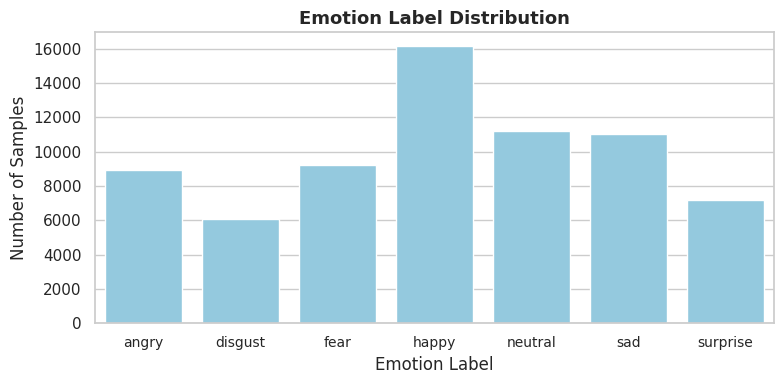

In [ ]:
# 6. Exploratory Data Analysis
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")
sns.countplot(
    x='label',
    data=combined_df,
    order=sorted(combined_df.label.unique()),
    color="skyblue"
)
plt.title("Emotion Label Distribution", fontsize=13, weight='bold')
plt.xlabel("Emotion Label", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

In order to have a visual representation of the data, an example of visualization function was executed. The `show_samples` function is used to randomly choose a given number of images (default is 20) of the integrative dataset and present them in a grid view with the attached emotion labels. Such qualitative evaluation is useful to ensure the images are properly named and always preprocessed (**grayscale**, **48x48** resolution). It also gives information about how varied facial expressions are among classes.

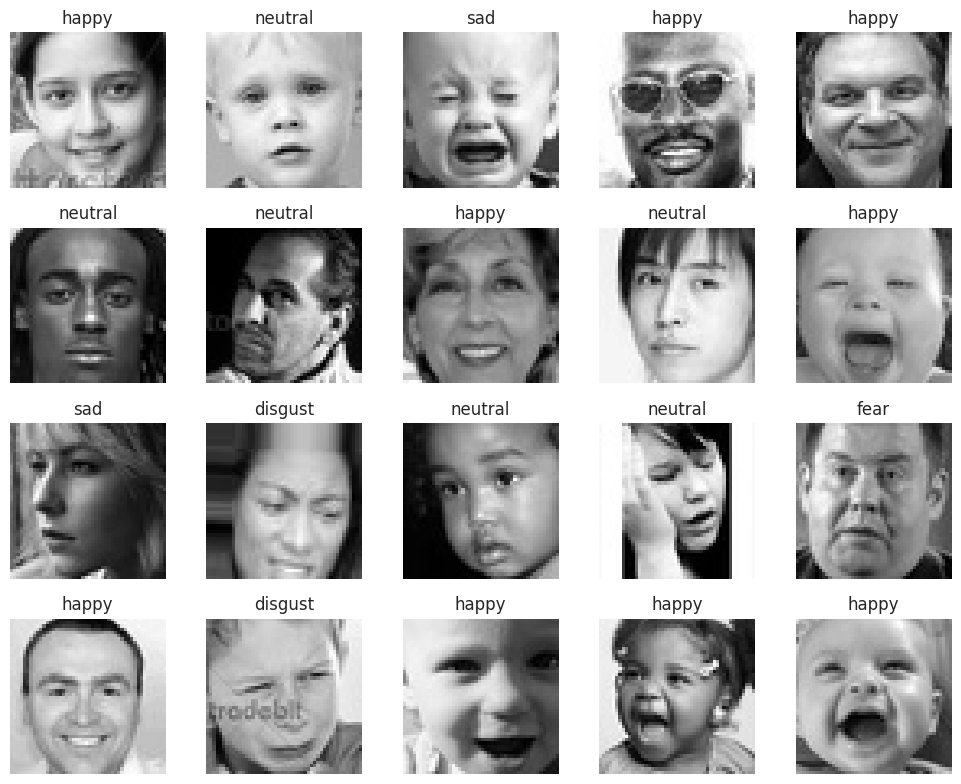

In [ ]:
def show_samples(n=20):
    samples = combined_df.sample(n)
    cols = 5
    rows = math.ceil(n/cols)
    plt.figure(figsize=(10,2*rows))
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        img = plt.imread(row.filepath)
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap='gray')
        plt.title(row.label)
        plt.axis('off')
    plt.tight_layout()
show_samples()

## Dataset Partitioning and Preprocessing


In order to prepare the dataset for model training, the combined dataset was first split into training (**72.25%** approx.), validation (**12.75%** approx.), and test (**15%**) sets using stratified sampling to preserve label distribution. The images were all resized to **48×48** pixels and batch size 64 was used during processing. The training data was also augmented with a pipeline of ImageDataGenerator, rescaling pixel values to [0, 1], random rotations (20degrees), shifts of width and height (15 percent), shear and zoom (15 percent), and horizontal flipping, which are known to prevent overfitting and enhance model generalization. Only the validation and test sets were rescaled but not augmented. To read grayscale images and labels in the dataframe, a custom generator function was constructed with `flow_from_dataframe()` having categorical class mode since it is a multiclass classification. Shuffling was set to be allowed during training but not in validation and testing to guarantee equal assessment.

* Convert images to float32 and pixel values normalization to `[0,1]`.
* Assign the categories of emotion the one-hot encoding to multi-classify the categories.
* Divided into **train (70 %)**, **validation (15 %)**, **test (15 %)** with stratification.
* Use **ImageDataGenerator** for on‑the‑fly data augmentation (random flips, shifts, rotations).



In [ ]:
IMG_SIZE = 48
BATCH = 64
NUM_CLASSES = combined_df.label.nunique()

# Split Dataset into train, validation and test sets
train_df, test_df = train_test_split(combined_df, test_size=0.15, stratify=combined_df.label, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1765, stratify=train_df.label, random_state=42)  # 0.1765*0.85 ≈ 0.15

# Define data augumentation strategy for training
datagen_train = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Define a simpler data generator for validation
datagen_val = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Custom function to create a data generator from a DataFrame
def make_generator(df, datagen, shuffle=True):
    return datagen.flow_from_dataframe(
        df,
        x_col='filepath',
        y_col='label',
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode='grayscale',
        class_mode='categorical',
        batch_size=BATCH,
        shuffle=shuffle
    )

# Create generators for training, validation, and test sets
train_gen = make_generator(train_df, datagen_train)
val_gen = make_generator(val_df, datagen_val, shuffle=False)
test_gen = make_generator(test_df, datagen_val, shuffle=False)


Found 48875 validated image filenames belonging to 7 classes.
Found 10476 validated image filenames belonging to 7 classes.
Found 10474 validated image filenames belonging to 7 classes.


# 4. Methods

## What is CNN?

A Convolutional Neural Network (CNN) is a particular sort of deep learning model used especially to handle and examine visual information, such as images.  As opposed to traditional neural networks, CNNs have a specific architecture to learn spatial features hierarchies on input images automatically and adaptively making them very effective in such tasks as image classification, object detection, facial recognition, etc. CNNs are especially useful in facial emotion recognition given that they will automatically identify minor changes in facial expressions without the intervention of manual feature engineering.

## CNN Architecture


Convolutional Neural Network (CNN) with VGG-style blocks was used, which is optimized to classify grayscale emotion on images 48x48 pixels. The model is implemented using three convolution layers with sequentially expanded filter settings (64, 128, and 256), after each convolution block, there is a batch normalization, ReLU activation, and max pooling. After each block, there are dropout layers to avoid overfitting. Lastly, there is a dense classifier that comes with dropout and batch normalization. Such configuration uses the AdamW optimizer with learning rate of 1e-3 and weight decay of 1e-4 which helps in generalization, and categorical cross-entropy loss which is applicable in multi-class classification.

```
Input (48×48×1 grayscale)
-> [Conv(64) -> BatchNorm -> Conv(64)] -> MaxPool -> Dropout(0.25)
-> [Conv(128) -> BatchNorm -> Conv(128)] -> MaxPool -> Dropout(0.25)
-> [Conv(256) -> BatchNorm -> Conv(256)] -> MaxPool -> Dropout(0.25)
-> Flatten -> Dense(256) -> BatchNorm -> Dropout(0.5)
-> Dense(7, softmax)
```

In [ ]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    model = keras.Sequential([
        # Enhanced Feature Extraction
        layers.Conv2D(64, 3, padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,197,703 (8.38 MB)

 Trainable params: 2,196,295 (8.38 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Model Training

To adequately train the CNN and overcome the class imbalance, a set of strategies are used. First, to ensure that less represented classes (e.g - *disgust*) were given more weight in terms of optimization process, class weights were calculated with `compute_class_weight` in sklearn. The model was assembled with AdamW optimizer and was trained up to 30 epochs. An EarlyStopping callback was applied to ensure the training was minimalized by checking the validation loss and restart loading the best set of weights when it was found that no further improvements were being made on the loss after five epochs to avoid overfitting and unnecessary computing.  In addition, a **ReduceLROnPlateau** scheduler which can dynamically adjust the learning rate by a factor of 0.5 if the validation loss stabilized for two consecutive epochs was used. The combination of weighted loss and early stopping together with adaptive learning rate scheduling helped the model to converge strongly while generalizing well on unseen data.

After training, the training and the validation accuracy increased quickly which means that extraction and learning of the features were successful. The validation accuracy increased by more than **70.9** percent against **25.9** percent with the loss falling significantly, confirming improved performance as time goes by. This `ReduceLROnPlateau` callback reduced the learning rate three times, which allowed tuning the performance in later epochs and avoid overfitting. Such training curve demonstrates the capability of the model to find a decent minimum and generalize reasonably on new data.

In [ ]:
EPOCHS = 30
early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight_dict = dict(zip(np.unique(train_df['label']), class_weights))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early, lr_scheduler],
    class_weight=class_weight_dict
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


764/764 ━━━━━━━━━━━━━━━━━━━━ 72s 72ms/step - accuracy: 0.2114 - loss: 2.1676 - val_accuracy: 0.2590 - val_loss: 2.0044 - learning_rate: 0.0010
Epoch 2/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.3703 - loss: 1.6241 - val_accuracy: 0.4413 - val_loss: 1.5113 - learning_rate: 0.0010
Epoch 3/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.5080 - loss: 1.3084 - val_accuracy: 0.5023 - val_loss: 1.3955 - learning_rate: 0.0010
Epoch 4/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.5491 - loss: 1.2026 - val_accuracy: 0.5905 - val_loss: 1.0746 - learning_rate: 0.0010
Epoch 5/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.5759 - loss: 1.1278 - val_accuracy: 0.5801 - val_loss: 1.1365 - learning_rate: 0.0010
Epoch 6/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.5910 - loss: 1.0887 - val_accuracy: 0.6340 - val_loss: 0.9675 - learning_rate: 0.0010
Epoch 7/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.6054 - loss: 1.0574

# 5. Results  

The validation and training accuracy graph indicates the level at which the CNN model learns per single epoch (21 epochs). First, the improvement curves of both measures are very steep, which indicates positive results of learning features. The training accuracy continued to rise steadily, while the validation accuracy drifted to 71 percent, which is good generalization and no overfitting. Occasional fluctuations in validation accuracy has been addressed by the reduction of learning rates with the help of `ReduceLROnPlateau` callback.  Overall, the close alignment between the two curves indicates a well-balanced model with high likelihood to be used in the real emotion recognition applications.

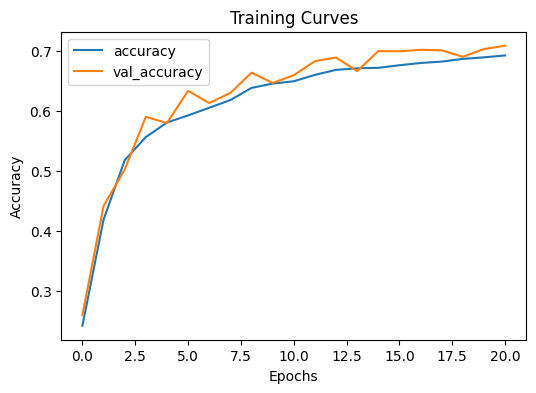

In [ ]:
# Results
history_df = pd.DataFrame(history.history)
history_df[['accuracy', 'val_accuracy']].plot(figsize=(6,4))
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.title("Training Curves")
plt.show()

## Test Evaluation and Confusion Matrix  

The final model obtained a test accuracy of 69.27% thereby showing that it generalizes on unseen data. As shown in the classification report, the model is most precise in terms of the labels of such factors as or *disgust* (F1-score: 0.95), and other emotions, such as or *fear* and or *sad* are being left behind by the degree of facial differences between them and their relative lack of prepopulation in the dataset. The confusion matrix expounds by stating that *fear* often was incorrectly labeled as either *neutral* or *sad*, and that there was moderate confusion between *angry* and both *neutral* and *sad*. This indicates that even though the model captures core emotional features effectively, there is still a problem of similarity in the expressions of different emotions such as *sad* and *fear*. However, the weighted average F1-score value of 0.69 survived a balanced performance of all classes.

  4/164 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7308 - loss: 0.7717 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


164/164 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6902 - loss: 0.8209
Test accuracy: 69.267%
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
              precision    recall  f1-score   support

       angry       0.59      0.64      0.62      1342
     disgust       0.98      0.93      0.95       915
        fear       0.56      0.34      0.42      1384
       happy       0.86      0.88      0.87      2423
     neutral       0.59      0.66      0.62      1677
         sad       0.53      0.60      0.56      1652
    surprise       0.76      0.79      0.77      1081

    accuracy                           0.69     10474
   macro avg       0.70      0.69      0.69     10474
weighted avg       0.69      0.69      0.69     10474



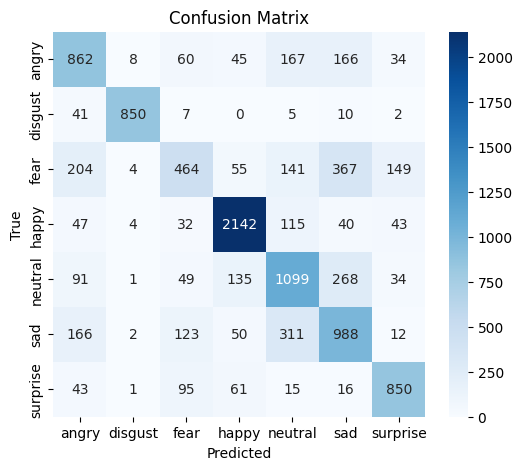

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.3%}")

y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred_labels = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_labels, target_names=test_gen.class_indices.keys()))

cm = confusion_matrix(y_true, y_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.ylabel("True"); plt.xlabel("Predicted"); plt.title("Confusion Matrix")
plt.show()

## Prediction

To illustrate the effectiveness of the model in practice,  a prediction pipeline was adopted in order to classify emotions using only one input image. The trained CNN model was saved then it was loaded again using `load_model()`. Then the input image is transformed to grayscale, resized to **48×48**, normalized, and then reshaped to fit the expected input of the model. The prediction function returns the predicted emotion label and a score of confidence, and visualizes the image together with the predicted class.

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt
#import cv2
#from tensorflow.keras.models import load_model
#from tensorflow.keras.preprocessing.image import img_to_array


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Emotion: happy
Confidence: 0.82


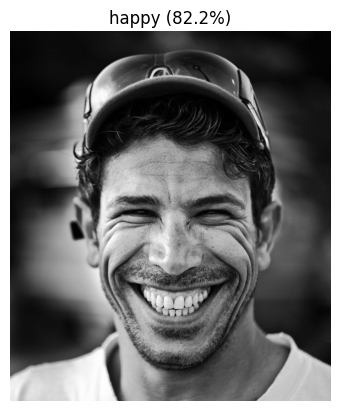

In [ ]:
#model.save('emotion_model_newCNN.h5')
model = load_model('emotion_model_newCNN.h5') # Load the saved Model

#Load and Preprocess the input image
def preprocess_image(img_path, img_size=48):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype("float32") / 255.0
    img = img.reshape((img_size, img_size, 1))
    return np.expand_dims(img, axis=0)          # shape (1, 48, 48, 1)


def predict_emotion(img_path, model, class_labels):
    img = preprocess_image(img_path)
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Predicted Emotion: {class_labels[predicted_class]}")
    print(f"Confidence: {confidence:.2f}")

    # Show the image
    img_display = cv2.imread(img_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.imshow(img_display)
    plt.title(f"{class_labels[predicted_class]} ({confidence*100:.1f}%)")
    plt.axis('off')
    plt.show()

class_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

#example happy detection
predict_emotion('/content/happy1.jpg', model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Emotion: sad
Confidence: 0.72


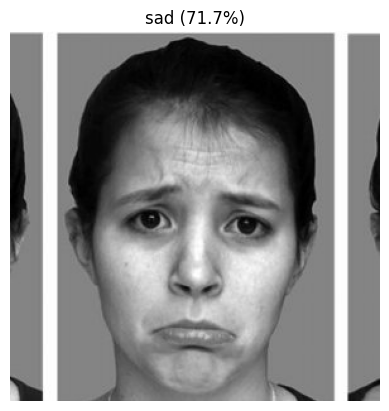

In [ ]:
#example sad detection
predict_emotion('/content/sad5.jpg', model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Emotion: fear
Confidence: 0.36


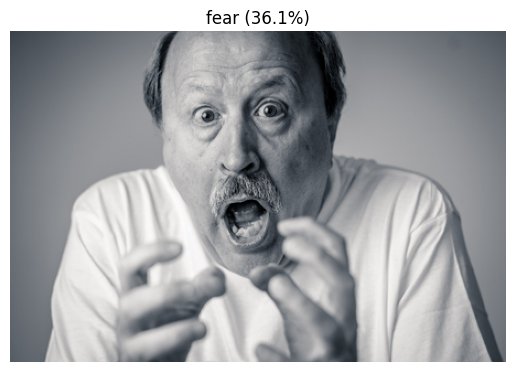

In [ ]:
#example fear detection
predict_emotion('/content/fear.jpg', model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Emotion: angry
Confidence: 0.82


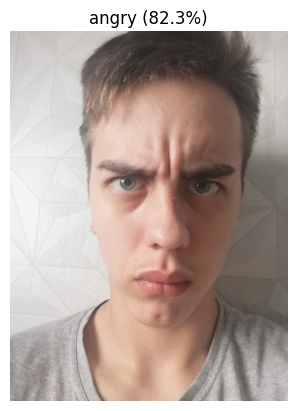

In [ ]:
#example anger detection
predict_emotion('/content/anger.jpg', model, class_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted Emotion: surprise
Confidence: 0.60


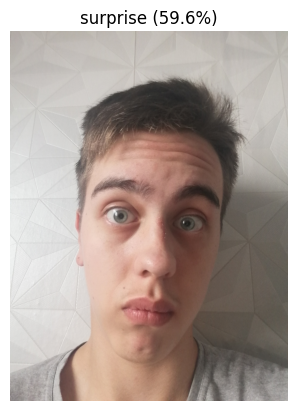

In [ ]:
#example surprised detection
predict_emotion('/content/surprised.jpg', model, class_labels)

# 6. Conclusions

In conclusion, the project was able to build, and test a convolutional neural network (CNN) to recognize facial emotions using a combination of two open-access facial expression data sets (FER and FER+). The proposed model, trained on class-balancing techniques as well as data augmentation, was capable of reaching a test accuracy of 69%. The methodology showed good results in recognizing well-defined expressions like happy, disgust, and surprise, but somewhat more complex emotions like fear and sad were harder which highlights the natural complexity of emotion identification based on facial expressions on a static image.

The outcomes fit the goal of the project defined as developing a scalable and reproducible emotion detection pipeline. Additionally, the code is modular, which allows experimenting flexibly on the one hand and possible integration with real-time systems on the other hand.

**Further gains:**  

* Include Transfer Learning using such pre-trained models as VGGFace or MobileNetV3 to make the topic of generalizability stronger.
* Attention Mechanisms can be used to ensure that the model focuses on significant areas of the face (e.g. eyes, mouth).
* Use as a Web or Mobile App and inference in real-time using the webcam.

---

### References
**Svitla** “The Use of CNN for Image Processing” (June 21, 2024). "https://svitla.com/blog/cnn-for-image-processing/"
